In [1]:
# Packages and data

library(tidyverse)
library(scales)
library(systemfonts)

dc_population <- read_csv("data/processed/dc-population-1990-2024.csv")



── Attaching core tidyverse packages ───────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.0     
Rows: 35 Columns: 3
── Column specification ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (1): NAME
dbl (2): year, value

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


# Plot the population over time

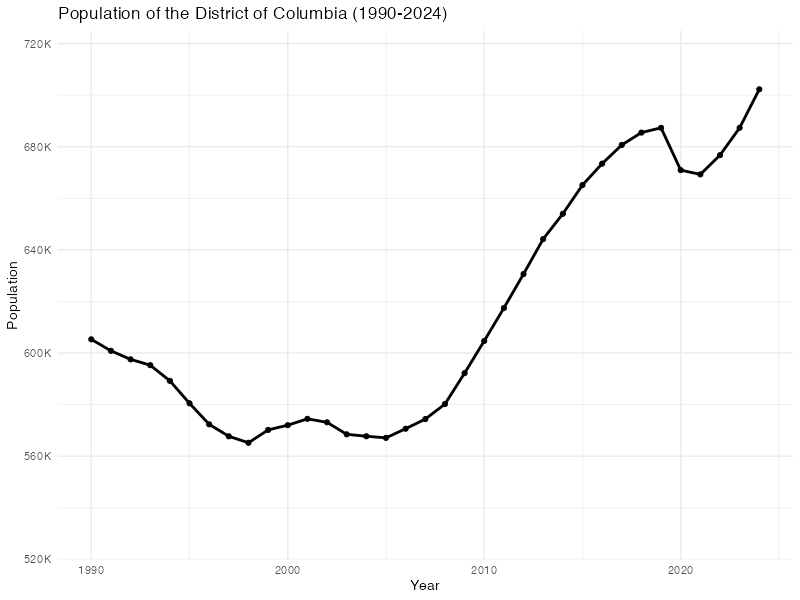

In [2]:
ymax <- max(dc_population$value)
ymin <- min(dc_population$value)
span <- ymax - ymin

yupper <- round(ymax + (1 / 6) * span, -3)
ylower <- round(ymin - (1 / 3) * span, -3)

population_plot <- dc_population |>
	ggplot(aes(x = as.integer(year), y = value)) +
	geom_line(linewidth = 1) +
	geom_point() +
	labs(
		title = "Population of the District of Columbia (1990-2024)",
		x = "Year",
		y = "Population"
	) +
	scale_y_continuous(
		limits = c(ylower, yupper),
		expand = expansion(0),
		labels = label_number(scale_cut = cut_short_scale())
	) +
	theme_minimal()

population_plot